# Séries temporais

- Obrigado a ter o campo data

## Objetivo
- Pegar um intervalo de tempo
- Entender o que aconteceu naquele intervalo

## Componentes
- Valor observados
    - Tendências
        - Pontos que estão crescente
    - Sazonalidade
        - Comportamento que se repete dentro de um intervalo de tempo
    - Aleatoriedade
        - Dados que não dá para explicar matematicamente

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from datetime import datetime # Manipulação de datas
from pandas.plotting import register_matplotlib_converters # Conversão
from statsmodels.tsa.seasonal import seasonal_decompose # Trabalhar com series temporais e fazer a decomposicao do grafico

In [5]:
base = pd.read_csv('AirPassengers.csv')

In [7]:
base.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [8]:
base.shape

(144, 2)

In [10]:
print(base.dtypes) # Visualiza o tipo de dado de cada coluna

Month          object
#Passengers     int64
dtype: object


## Conversão de dados

### Converter objeto para data

In [14]:
converter = lambda dates: datetime.strptime(dates, '%Y-%m') # Regra para Converter string para data Mes Ano

# Converter a coluna month para data (Mês-Ano)
base = pd.read_csv('AirPassengers.csv',
                   index_col='Month',
                   parse_dates=['Month'],
                   date_parser=converter)

/tmp/ipykernel_7995/3433355184.py:4: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  base = pd.read_csv('AirPassengers.csv',


In [16]:
base.index # Conferir resultados

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

In [17]:
ts = base['#Passengers'] # Colocar a coluna passageiros de volta na base
ts

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [21]:
ts[1] # Conferir indice 1 da coluna passageiros

/tmp/ipykernel_7995/779833446.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ts[1] # Conferir indice 1 da coluna passageiros


np.int64(118)

In [22]:
ts['1949-02'] # Quantos passageiros tinham em fevereiro de 1949

,#Passengers
Month,
1949-02-01,118


In [26]:
ts['1950-01-01':'1950-07-01'] # Qtd de passageiros que tem registro entre um período

,#Passengers
Month,
1950-01-01,115
1950-02-01,126
1950-03-01,141
1950-04-01,135
1950-05-01,125
1950-06-01,149
1950-07-01,170


In [27]:
ts.index.max() # Valor máximo da data

Timestamp('1960-12-01 00:00:00')

In [28]:
ts.index.min() # Valor mínimo da data

Timestamp('1949-01-01 00:00:00')

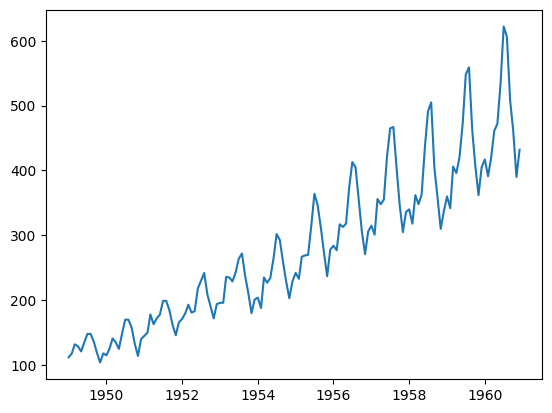

In [29]:
plt.plot(ts) # Gerar grafico da analise

#### Agrupamento por ano

In [30]:
ts_ano = ts.resample('A').sum() # Agrupamento por ano
ts_ano

/tmp/ipykernel_7995/2709752598.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  ts_ano = ts.resample('A').sum()


,#Passengers
Month,
1949-12-31,1520
1950-12-31,1676
1951-12-31,2042
1952-12-31,2364
1953-12-31,2700
1954-12-31,2867
1955-12-31,3408
1956-12-31,3939
1957-12-31,4421


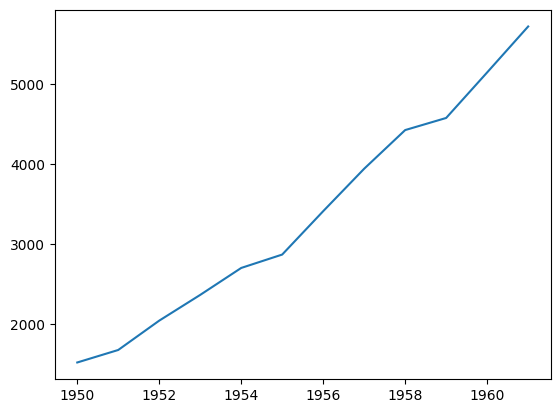

In [31]:
plt.plot(ts_ano) # Gerar grafico da analise

#### Agrupamento por mês

In [33]:
ts_mes = ts.groupby(lambda x: x.month).sum() # somar os meses de todos os anos
ts_mes

,#Passengers
Month,
1,2901
2,2820
3,3242
4,3205
5,3262
6,3740
7,4216
8,4213
9,3629


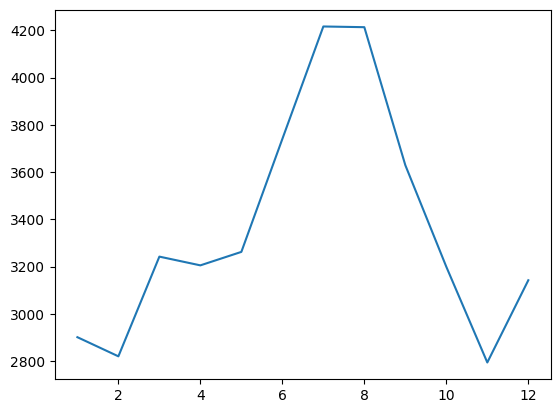

In [34]:
plt.plot(ts_mes) # Gerar grafico da analise

## Decomposição

In [37]:
decomposicao = seasonal_decompose(ts) # Cria funcao de decomposicao

In [39]:
tendencia = decomposicao.trend # Pegar tendencia
tendencia

,trend
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
...,...
1960-08-01,NaN
1960-09-01,NaN
1960-10-01,NaN


In [40]:
sazonal = decomposicao.seasonal # Pegar sazonalidade
sazonal

,seasonal
Month,
1949-01-01,-24.748737
1949-02-01,-36.188131
1949-03-01,-2.241162
1949-04-01,-8.036616
1949-05-01,-4.506313
...,...
1960-08-01,62.823232
1960-09-01,16.520202
1960-10-01,-20.642677


In [41]:
aleatorio = decomposicao.resid # Pegar aleatoriedade
aleatorio

,resid
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
...,...
1960-08-01,NaN
1960-09-01,NaN
1960-10-01,NaN


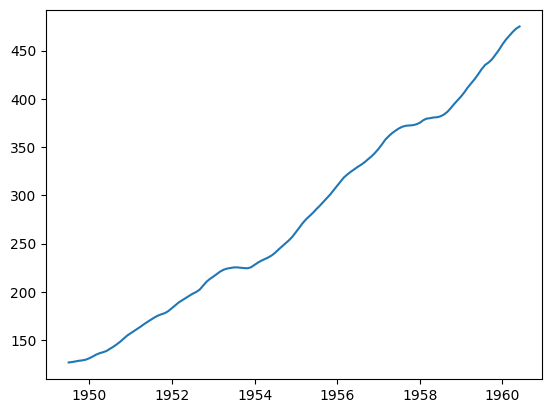

In [42]:
plt.plot(tendencia) # Grafico tendencia

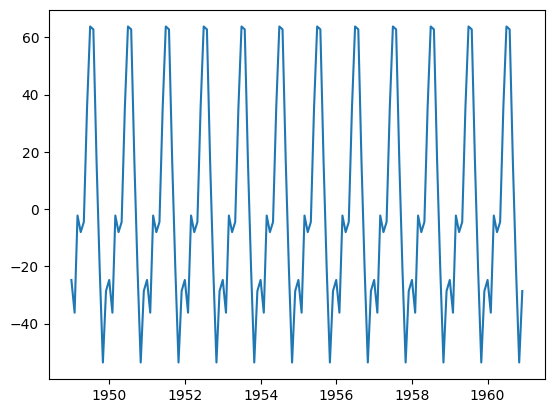

In [43]:
plt.plot(sazonal)

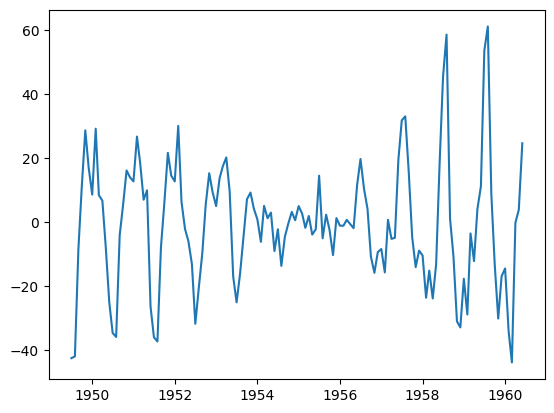

In [44]:
plt.plot(aleatorio)

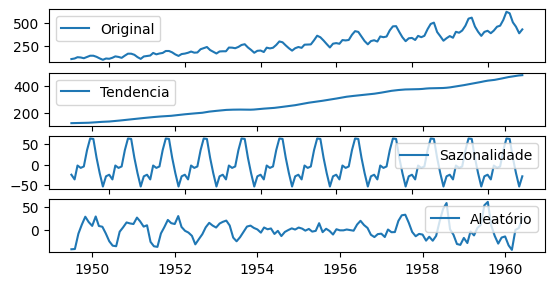

In [47]:
plt.subplot(6,1,1)
plt.plot(ts, label='Original')
plt.legend(loc='best')

plt.subplot(6,1,2)
plt.plot(tendencia, label='Tendencia')
plt.legend(loc='best')

plt.subplot(6,1,3)
plt.plot(sazonal, label='Sazonalidade')
plt.legend(loc='best')

plt.subplot(6,1,4)
plt.plot(aleatorio, label='Aleatório')
plt.legend(loc='best')